# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture
**Project Theme:** Seasonal Agriculture Performance
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.

However, raw agricultural data does not clearly explain how agricultural performance changes across seasons or what patterns can be observed in different seasonal conditions. The goal of this notebook is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

## 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

## 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `DATASET.csv`

The notebook is designed so that the CSV can be uploaded/placed in the same folder as this notebook.

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
# Load the dataset

file_path = "DATASET.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4. Initial Data Understanding

In [3]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [4]:
# First 5 rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [5]:
# Last 5 rows

df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [6]:
# Random sample of records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [7]:
# Column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [8]:
# Data types and non-null counts

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

## 5. Data Cleaning

Before any analysis, the dataset needs to be checked for missing values, duplicate records and inconsistent data types.

In [9]:
# Check missing values

missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

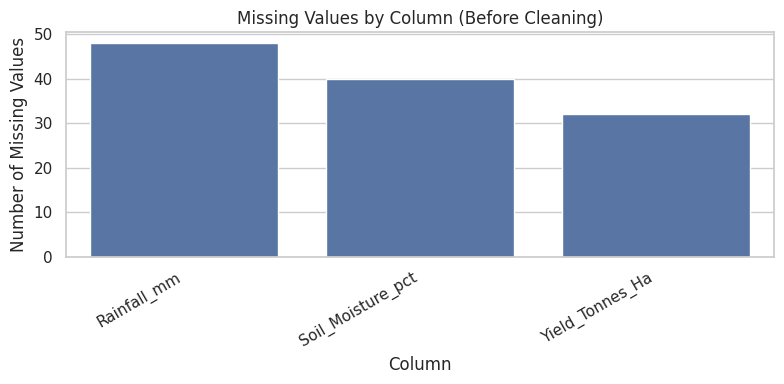

In [10]:
# Visualize missing values

plt.figure(figsize=(8, 4))
missing_plot = missing[missing > 0]
if len(missing_plot) > 0:
    sns.barplot(x=missing_plot.index, y=missing_plot.values, color="#4C72B0")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Number of Missing Values")
    plt.xlabel("Column")
    plt.title("Missing Values by Column (Before Cleaning)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

In [11]:
# Duplicate records

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [12]:
# Remove duplicate rows, if any

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4000, 28)


In [13]:
# Check data types again

df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

### Checking unique values for categorical columns

This helps confirm that categorical fields (State, District, Crop, Season, Irrigation Method) do not contain typos, inconsistent spellings or unexpected categories.

In [14]:
# Check unique values for categorical columns

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(sorted(df[col].dropna().unique())[:20])


Farm_ID:
4000 unique values
['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007', 'SF10008', 'SF10009', 'SF10010', 'SF10011', 'SF10012', 'SF10013', 'SF10014', 'SF10015', 'SF10016', 'SF10017', 'SF10018', 'SF10019', 'SF10020']

State:
8 unique values
['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']

District:
10 unique values
['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']

Crop:
8 unique values
['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']

Season:
3 unique values
['Kharif', 'Rabi', 'Zaid']

Irrigation_Method:
4 unique values
['Drip', 'Flood', 'Rainfed', 'Sprinkler']


### Missing Value Treatment

Choose an appropriate strategy based on the nature of each variable.

Three numeric columns contain missing values: `Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha`. Since environmental and yield values differ meaningfully by **Season** and **Crop**, missing values are filled using the median of the corresponding Season-Crop group rather than a single overall median or a constant like zero. This keeps the imputed values consistent with the conditions under which each record was collected. Any values that still remain missing (e.g. a Season-Crop group with no other observations) are filled with the overall column median as a fallback.

In [15]:
# Missing value treatment: group-wise median imputation

for col in ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]:
    df[col] = df.groupby(["Season", "Crop"])[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

print("Total missing values after treatment:", df.isnull().sum().sum())

Total missing values after treatment: 0


## 6. Statistical Analysis

Perform descriptive statistical analysis to understand the distribution and variation of the data.

In [16]:
# Separate numerical and categorical columns

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)
print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [17]:
# Descriptive statistics

stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]
stats.round(2)

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.90,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.72,288.42,80.00,370.42,581.00,835.95,"1,395.20","1,315.20",465.52
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.78,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.70,8.00,21.70,26.40,31.30,47.00,39.00,9.60
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


**Interpretation:** Farm size, rainfall and temperature vary widely across records, which is expected given that the data spans 8 states and 3 seasons. `Yield_Tonnes_Ha` has a large range mainly because Sugarcane yields are far higher (tonnes/ha) than other crops, so this variable should be interpreted crop-wise rather than as a single distribution. `Profit_INR` has a wide IQR and, as shown later, includes a large share of loss-making farms, particularly in the Zaid season.

## 7. Univariate Analysis

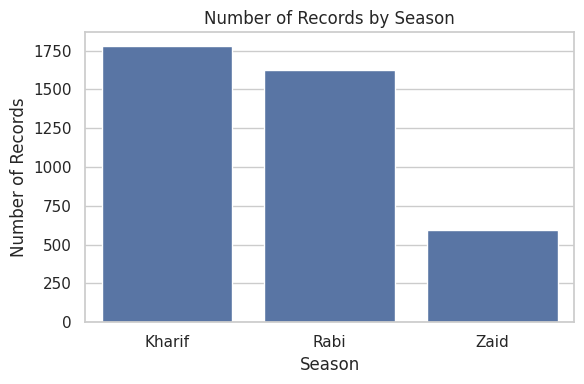

In [18]:
# Number of records by season

plt.figure(figsize=(6, 4))
season_order = df["Season"].value_counts().index
sns.countplot(data=df, x="Season", order=season_order, color="#4C72B0")
plt.title("Number of Records by Season")
plt.ylabel("Number of Records")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

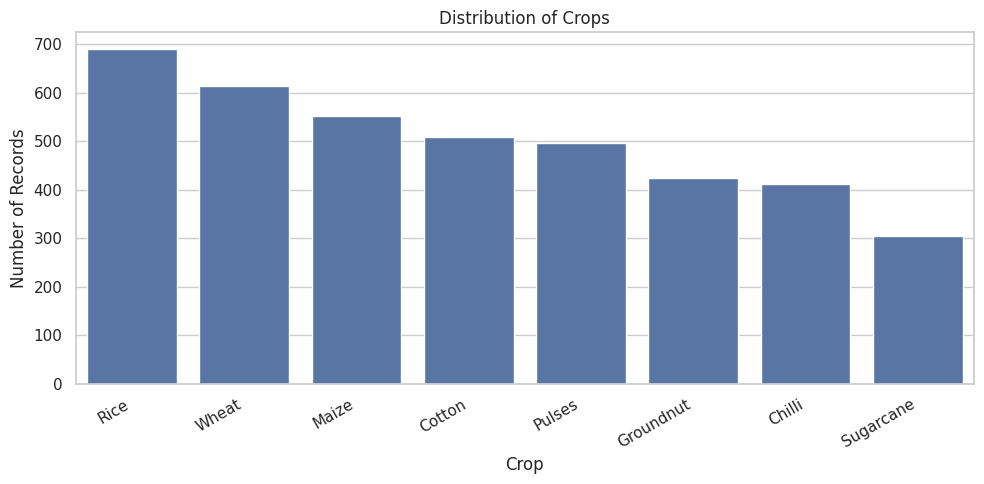

In [19]:
# Distribution of crops

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index, color="#4C72B0")
plt.xticks(rotation=30, ha="right")
plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

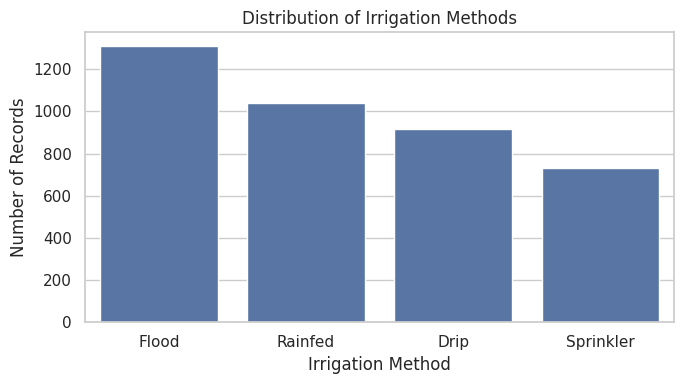

In [20]:
# Distribution of irrigation methods

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Irrigation_Method", order=df["Irrigation_Method"].value_counts().index, color="#4C72B0")
plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

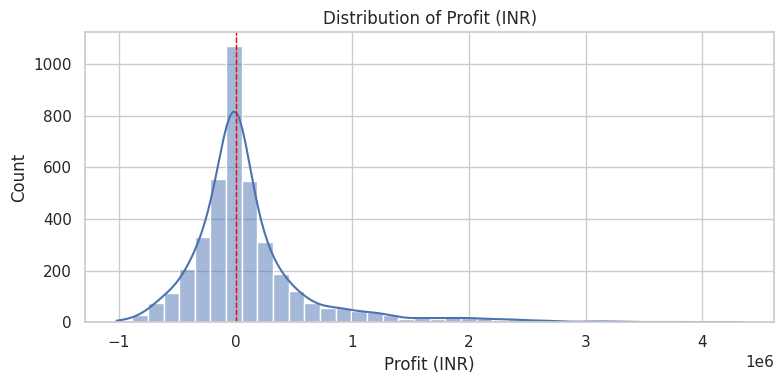

In [21]:
# Distribution of profit

plt.figure(figsize=(8, 4))
sns.histplot(df["Profit_INR"], bins=40, color="#4C72B0", kde=True)
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.title("Distribution of Profit (INR)")
plt.xlabel("Profit (INR)")
plt.tight_layout()
plt.show()

## 8. Bivariate Analysis

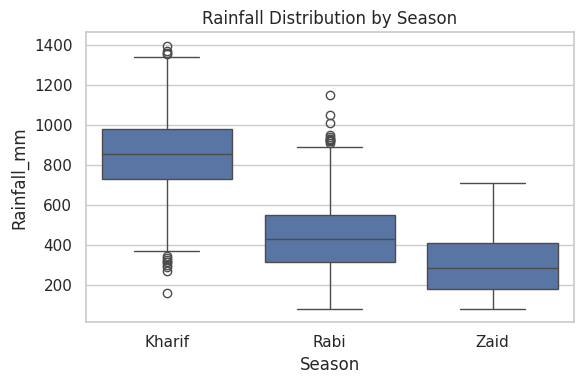

In [22]:
# Rainfall across seasons

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Season", y="Rainfall_mm", order=["Kharif", "Rabi", "Zaid"], color="#4C72B0")
plt.title("Rainfall Distribution by Season")
plt.tight_layout()
plt.show()

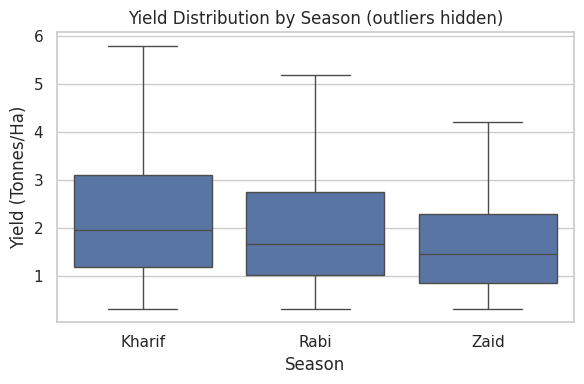

In [23]:
# Yield across seasons

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Season", y="Yield_Tonnes_Ha", order=["Kharif", "Rabi", "Zaid"], color="#4C72B0", showfliers=False)
plt.title("Yield Distribution by Season (outliers hidden)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

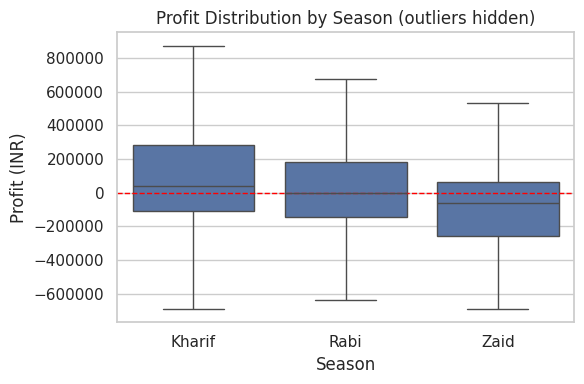

In [24]:
# Profit across seasons

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Season", y="Profit_INR", order=["Kharif", "Rabi", "Zaid"], color="#4C72B0", showfliers=False)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title("Profit Distribution by Season (outliers hidden)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

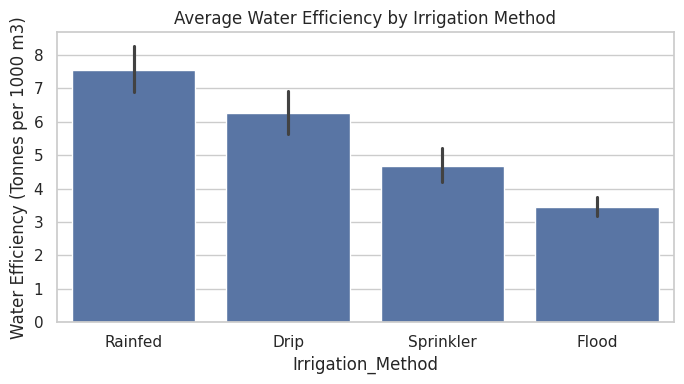

In [25]:
# Water efficiency by irrigation method

plt.figure(figsize=(7, 4))
sns.barplot(data=df, x="Irrigation_Method", y="Water_Efficiency_t_per_1000m3",
            order=df.groupby("Irrigation_Method")["Water_Efficiency_t_per_1000m3"].mean().sort_values(ascending=False).index,
            color="#4C72B0")
plt.title("Average Water Efficiency by Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1000 m3)")
plt.tight_layout()
plt.show()

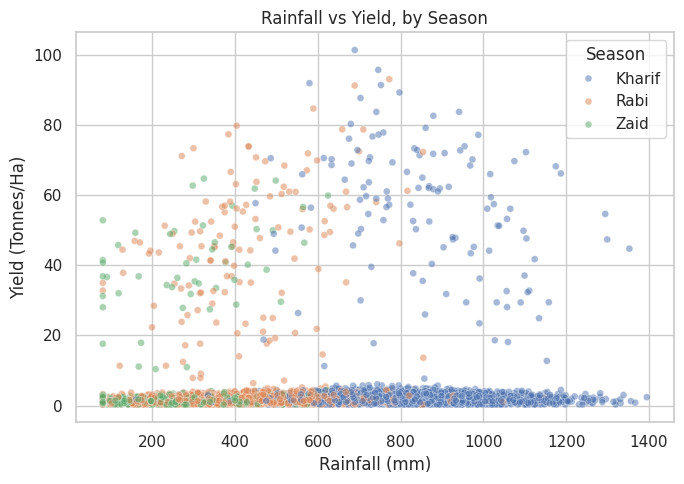

In [26]:
# Relationship between rainfall and yield

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season",
                 hue_order=["Kharif", "Rabi", "Zaid"], alpha=0.5, s=25)
plt.title("Rainfall vs Yield, by Season")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

## 9. Multivariate Analysis

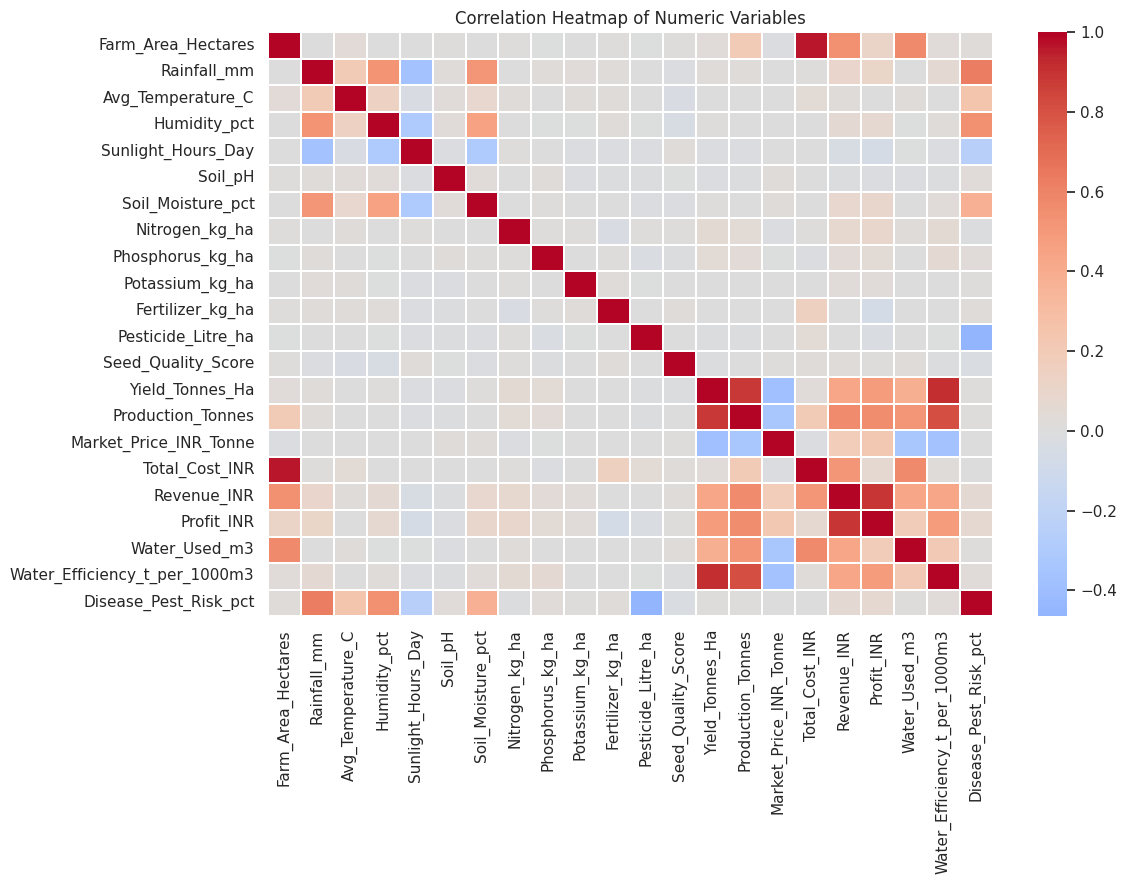

In [27]:
# Correlation among numeric variables

plt.figure(figsize=(12, 9))
corr = df[numeric_columns].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()

In [28]:
# Strongest correlations with Yield and Profit

print("Top correlations with Yield_Tonnes_Ha:")
print(corr["Yield_Tonnes_Ha"].sort_values(ascending=False)[1:6])
print("\nTop correlations with Profit_INR:")
print(corr["Profit_INR"].sort_values(ascending=False)[1:6])

Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3   0.92
Production_Tonnes               0.89
Profit_INR                      0.49
Revenue_INR                     0.43
Water_Used_m3                   0.39
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Revenue_INR                     0.89
Production_Tonnes               0.55
Water_Efficiency_t_per_1000m3   0.49
Yield_Tonnes_Ha                 0.49
Market_Price_INR_Tonne          0.23
Name: Profit_INR, dtype: float64


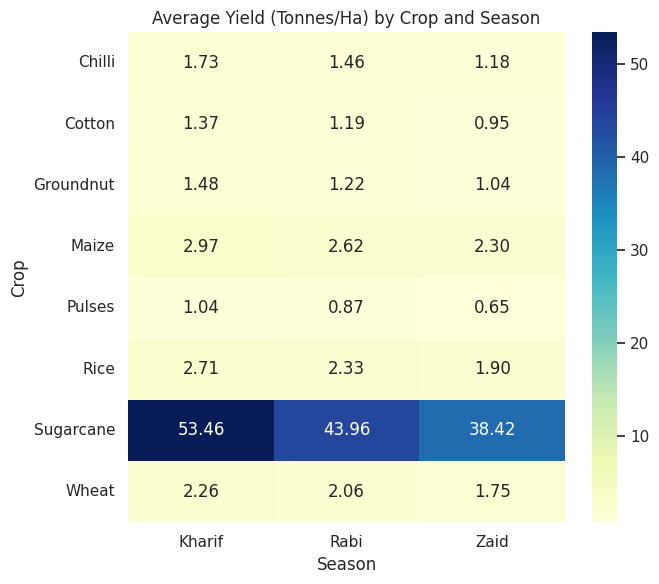

In [29]:
# Average yield by season and crop

pivot_yield = df.pivot_table(values="Yield_Tonnes_Ha", index="Crop", columns="Season", aggfunc="mean")
pivot_yield = pivot_yield[["Kharif", "Rabi", "Zaid"]]

plt.figure(figsize=(7, 6))
sns.heatmap(pivot_yield.round(2), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield (Tonnes/Ha) by Crop and Season")
plt.tight_layout()
plt.show()

In [30]:
# Season and irrigation method together

irr_season = pd.crosstab(df["Season"], df["Irrigation_Method"])
irr_season = irr_season.reindex(["Kharif", "Rabi", "Zaid"])
irr_season

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


## 10. Comparing Agricultural Performance Across Seasons

This section brings together the key metrics season by season to directly compare performance.

In [31]:
# Seasonal summary table

seasonal_summary = df.groupby("Season")[[
    "Rainfall_mm", "Avg_Temperature_C", "Yield_Tonnes_Ha", "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3", "Profit_INR", "Disease_Pest_Risk_pct"
]].mean().round(2)

seasonal_summary = seasonal_summary.reindex(["Kharif", "Rabi", "Zaid"])
seasonal_summary

,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,852.10,28.45,5.63,"6,102.20",5.89,"178,914.65",54.47
Rabi,435.95,23.49,5.09,"5,846.99",5.19,"87,689.47",40.48
Zaid,299.16,31.04,4.64,"6,419.89",4.41,"-24,804.82",38.22


In [32]:
# Profit margin and share of loss-making farms by season

season_financials = df.groupby("Season").agg(
    Total_Revenue=("Revenue_INR", "sum"),
    Total_Profit=("Profit_INR", "sum")
)
season_financials["Profit_Margin_pct"] = (season_financials["Total_Profit"] / season_financials["Total_Revenue"] * 100).round(2)
season_financials["Loss_Making_Farms_pct"] = df.assign(loss=df["Profit_INR"] < 0).groupby("Season")["loss"].mean().mul(100).round(1)

season_financials = season_financials.reindex(["Kharif", "Rabi", "Zaid"])
season_financials

,Total_Revenue,Total_Profit,Profit_Margin_pct,Loss_Making_Farms_pct
Season,,,,
Kharif,1264369200,318289158,25.17,42.20
Rabi,978682881,142670768,14.58,51.10
Zaid,308388111,-14734066,-4.78,64.50


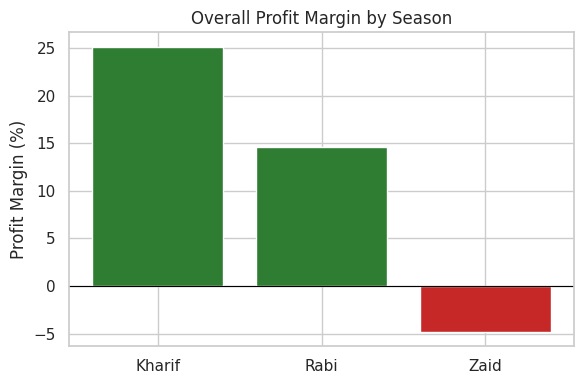

In [33]:
# Visual comparison: profit margin by season

plt.figure(figsize=(6, 4))
colors = ["#2E7D32" if v >= 0 else "#C62828" for v in season_financials["Profit_Margin_pct"]]
plt.bar(season_financials.index, season_financials["Profit_Margin_pct"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Overall Profit Margin by Season")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

## 11. Key Findings

- **Kharif is the most profitable and Zaid the weakest season overall.** Kharif shows the highest average rainfall, the highest average yield and the highest overall profit margin (~25%). Zaid, the driest and hottest season, shows a **negative overall profit margin**, and roughly **6 in 10 Zaid farms operate at a loss**, compared to about 4 in 10 in Kharif.
- **Water efficiency does not follow water usage.** Flood irrigation uses the most water per farm (~8,026 m³ on average) but has the lowest water efficiency (3.44 tonnes per 1000 m³). Rainfed plots show the highest efficiency ratio, largely because they draw very little supplemental water to begin with; among the actively managed methods, Drip is clearly more water-efficient than Sprinkler or Flood (6.27 vs 4.67 vs 3.44 tonnes per 1000 m³), making it the more sustainable choice where irrigation infrastructure is being upgraded.
- **Yield is strongly linked to water efficiency**, not to fertilizer or nutrient levels — the correlation between `Yield_Tonnes_Ha` and `Water_Efficiency_t_per_1000m3` is far stronger than with Nitrogen, Phosphorus or Potassium application rates.
- **Sugarcane yields dominate every season** by a wide margin, so yield figures should always be interpreted per-crop rather than as a single combined distribution.
- **Disease and pest risk is highest in Kharif** (the wettest, most humid season) and lowest in Zaid, consistent with pests and disease pressure rising with humidity and rainfall.
- **Profit is driven mainly by revenue and yield**, not by farm size — `Farm_Area_Hectares` has a comparatively weak correlation with `Profit_INR`, suggesting that smaller, well-managed farms can perform as well as larger ones.

## 12. Conclusion and Recommendations

The analysis confirms that agricultural performance in this dataset varies meaningfully across seasons rather than remaining constant throughout the year. Kharif benefits from favourable rainfall and delivers the strongest financial outcomes, Rabi performs moderately, and Zaid consistently underperforms on yield, water efficiency and profitability.

**Recommendations:**

1. **Re-evaluate Zaid-season cultivation.** With a negative overall profit margin and the highest share of loss-making farms, crop choice, irrigation method and input costs for the Zaid season should be reviewed before continuing the current cropping pattern.
2. **Encourage drip irrigation where feasible**, especially outside the Kharif season, since it shows better water efficiency and yield outcomes than flood irrigation for comparable water use.
3. **Strengthen pest and disease monitoring during Kharif**, where the combination of high rainfall and humidity coincides with the highest disease/pest risk scores in the dataset.
4. **Support crop diversification decisions with per-crop yield data** rather than farm area alone, since yield and profit are more closely tied to crop choice and resource efficiency than to farm size.

Overall, seasonal timing, irrigation method and crop selection appear to be more influential on agricultural performance than farm size, supporting more season-aware planning going forward.